In [1]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

In [2]:
# Coordinates and Parametrization from image_0c5721.png
x1, x2 = sp.symbols('x1 x2', real=True)
r = sp.Matrix([sp.cos(x2)*sp.cos(x1), sp.cos(x2)*sp.sin(x1), sp.sin(x2)])
jac_r = r.jacobian([x1, x2])

display(jac_r)

G_u = sp.simplify(jac_r.T * jac_r)
display(G_u)

Matrix([
[-sin(x1)*cos(x2), -sin(x2)*cos(x1)],
[ cos(x1)*cos(x2), -sin(x1)*sin(x2)],
[               0,          cos(x2)]])

Matrix([
[cos(x2)**2, 0],
[         0, 1]])

In [4]:
coords = [x1, x2]

V1 = sp.Matrix([[7], [0]])
V2 = sp.Matrix([[2], [7]])
V3 = sp.Matrix([[7], [sp.pi]])

Lv_g1 = DG503.lie_derivative_metric(G_u, V1,coords)
Lv_g2 = DG503.lie_derivative_metric(G_u, V2,coords)
Lv_g3 = DG503.lie_derivative_metric(G_u, V3,coords)

display(Lv_g1)
display(Lv_g2)
display(Lv_g3)

Matrix([
[0, 0],
[0, 0]])

Matrix([
[-7*sin(2*x2), 0],
[           0, 0]])

Matrix([
[-pi*sin(2*x2), 0],
[            0, 0]])

In [6]:
chris = DG503.christoffel_symbols(G_u, coords)
display(chris)

{(0, 0, 0): 0,
 (0, 0, 1): sin(2*x2)/2,
 (0, 1, 0): -tan(x2),
 (0, 1, 1): 0,
 (1, 0, 0): -tan(x2),
 (1, 0, 1): 0,
 (1, 1, 0): 0,
 (1, 1, 1): 0}

In [8]:
a, t  = sp.symbols('a t', real=True)

gamma = sp.Matrix([t, a])

gamma_dot = gamma.diff(t)

G_gamma = G_u.subs({x1: gamma[0], x2: gamma[1]})

# finding the g length of the curve gamm

acceleration = DG503.curve_acceleration(G_u, gamma, t, coords)
display(acceleration)

curvature = DG503.g_norm(G_gamma, acceleration)
display(curvature)

a = sp.solve(curvature, a)
display(a)

Matrix([
[         0],
[sin(2*a)/2]])

Abs(sin(2*a))/2

[0, pi/2]

It has to be geodesic if the curvature and acceleration is 0 so if its is geodesic. It is only 0 if a = n*pi/2

In [9]:
R_tensor = DG503.curvature_tensor(G_u, coords)
display(R_tensor[0,1,1,0])

cos(x2)**2

In [11]:
a = sp.symbols('a', real=True)

W = sp.Matrix([sp.sin(t*sp.sin(a))/sp.cos(a), sp.cos(t*sp.sin(a))])
display(W)

cov_along = sp.simplify(DG503.covariant_derivative_along_curve(G_u, gamma, W, t, coords))
display(cov_along)

Matrix([
[sin(t*sin(a))/cos(a)],
[       cos(t*sin(a))]])

Matrix([
[0],
[0]])

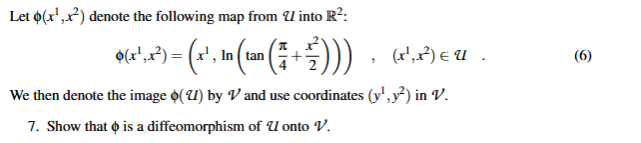

In [37]:
y1, y2, x1, x2 = sp.symbols('y1 y2 x1 x2', real=True)

phi = sp.Matrix([x1,sp.ln(sp.tan(sp.pi/4+x2/2))])
display(phi)

J = phi.jacobian([x1, x2])
display(J)

det_J = sp.simplify(J.det())
display(det_J)

# If sol is the result of solve
sol = sp.solve([sp.Eq(phi[0], y1), sp.Eq(phi[1], y2)], (x1, x2))


display(sol)

phi_inv = sp.Matrix([sol[0]]).T
display(phi_inv)

J_inv = sp.simplify(phi_inv.jacobian([y1,y2]))
display(J_inv)

J_J_inv = sp.simplify(J*J_inv)
display(J_J_inv.subs({y1:phi[0],y2:phi[1]}).simplify())

# Rewrite in terms of exponentials to break down the cosh(log(...)) barrier
verification = (J * J_inv).subs({y1: phi[0], y2: phi[1]})
display(verification.rewrite(sp.exp).simplify())

Matrix([
[                   x1],
[log(tan(x2/2 + pi/4))]])

Matrix([
[1,                                              0],
[0, (tan(x2/2 + pi/4)**2/2 + 1/2)/tan(x2/2 + pi/4)]])

1/cos(x2)

[(y1, 2*atan(exp(y2)) - pi/2)]

Matrix([
[                    y1],
[2*atan(exp(y2)) - pi/2]])

Matrix([
[1,          0],
[0, 1/cosh(y2)]])

Matrix([
[1,                                       0],
[0, 1/(cos(x2)*cosh(log(tan(x2/2 + pi/4))))]])

Matrix([
[1, 0],
[0, 1]])

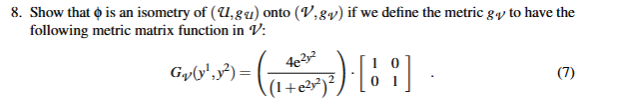

In [ ]:
G_v = sp.simplify(4*sp.E**(2*y2)/(1+sp.E**(2*y2))**2*sp.eye(2))
display(G_v)

display(G_u)


display(sp.simplify(J_inv.T*G_u.subs({x1:phi_inv[0],x2:phi_inv[1]})*J_inv))

display(G_v)



Matrix([
[cosh(y2)**(-2),              0],
[             0, cosh(y2)**(-2)]])

Matrix([
[cos(x2)**2, 0],
[         0, 1]])

Matrix([
[cosh(y2)**(-2),              0],
[             0, cosh(y2)**(-2)]])

Matrix([
[cosh(y2)**(-2),              0],
[             0, cosh(y2)**(-2)]])

: 

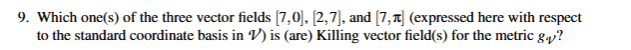

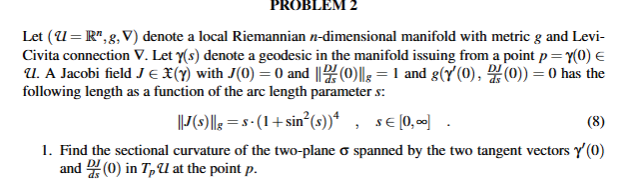